In [40]:
import os
import mlflow

os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
mlflow.set_tracking_uri("sqlite:///mlruns.db")

print("Tracking URI:", mlflow.get_tracking_uri())


Tracking URI: sqlite:///mlruns.db


In [41]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [43]:
import os
import pandas as pd

csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [44]:
print(df.shape)

(284807, 31)


In [45]:
class_counts = df['Class'].value_counts()

class_percentages = df['Class'].value_counts(normalize=True) * 100

class_balance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})

display(class_balance_df)

,Count,Percentage
Class,,
0,284315,99.827251
1,492,0.172749


In [46]:
print(df.info)

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [47]:
print(df.describe)

<bound method NDFrame.describe of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599

In [48]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [49]:
# Display the minimum and maximum values of the 'Time' column
min_time = df['Time'].min()
max_time = df['Time'].max()

print(f"Minimum 'Time' value: {min_time}")
print(f"Maximum 'Time' value: {max_time}")
print(f"Range of 'Time' column: {max_time - min_time} seconds")

Minimum 'Time' value: 0.0
Maximum 'Time' value: 172792.0
Range of 'Time' column: 172792.0 seconds


In [50]:
display(df['Amount'].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [51]:
display(df.loc[:, 'V1':'V5'].describe())

,V1,V2,V3,V4,V5
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01


### Chronological Train/Test Split

In [52]:
from sklearn.model_selection import train_test_split

# Sort the DataFrame by 'Time' to ensure chronological order
df_sorted = df.sort_values(by='Time').reset_index(drop=True)

# Define features (X) and target (y)
X = df_sorted.drop('Class', axis=1)
y = df_sorted['Class']

# Determine the split point (e.g., 80% for training, 20% for testing)
split_index = int(len(df_sorted) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Fraud instances in training set: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"Fraud instances in testing set: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

Training set shape: (227845, 30)
Testing set shape: (56962, 30)
Fraud instances in training set: 417 (0.18%)
Fraud instances in testing set: 75 (0.13%)


### Scaling 'Amount' and Reasoning for 'Time'

In [53]:
from sklearn.preprocessing import StandardScaler

# Fit one scaler per feature so each artifact retains the correct statistics.
amount_scaler = StandardScaler()
X_train['Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = amount_scaler.transform(X_test[['Amount']])

time_scaler = StandardScaler()
X_train['Time'] = time_scaler.fit_transform(X_train[['Time']])
X_test['Time'] = time_scaler.transform(X_test[['Time']])

print("Scaled 'Amount' and 'Time' columns in training set (first 5 rows):")
display(X_train[['Amount', 'Time']].head())
print("Scaled 'Amount' and 'Time' columns in testing set (first 5 rows):")
display(X_test[['Amount', 'Time']].head())

Scaled 'Amount' and 'Time' columns in training set (first 5 rows):


C:\Users\user\AppData\Local\Temp\ipykernel_13640\487250229.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Amount'] = amount_scaler.fit_transform(X_train[['Amount']])
C:\Users\user\AppData\Local\Temp\ipykernel_13640\487250229.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Amount'] = amount_scaler.transform(X_test[['Amount']])
C:\Users\user\AppData\Local\Temp\ipykernel_13640\487250229.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

,Amount,Time
0,0.234708,-2.000787
1,-0.351831,-2.000787
2,1.149027,-2.000761
3,0.130438,-2.000761
4,-0.083172,-2.000736


Scaled 'Amount' and 'Time' columns in testing set (first 5 rows):


,Amount,Time
227845,-0.162972,1.675833
227846,-0.302890,1.675858
227847,-0.331832,1.675858
227848,-0.334666,1.675858
227849,1.476568,1.675883


### Train a Simple Classifier (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=42, class_weight=None)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Evaluate the Classifier

Accuracy: 0.9994
Recall at threshold 0.15: 0.6800
Precision at threshold 0.15: 0.7612
F1-Score (Fraud Class): 0.7000
AUC-ROC: 0.9755

Classification Report (per-class):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.93      0.56      0.70        75

    accuracy                           1.00     56962
   macro avg       0.97      0.78      0.85     56962
weighted avg       1.00      1.00      1.00     56962



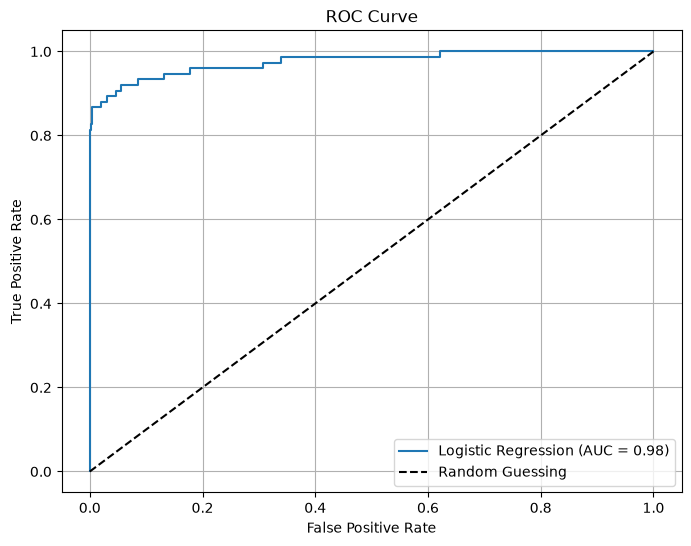

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

custom_threshold = 0.15
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall at threshold {custom_threshold}: {recall_score(y_test, y_pred_custom):.4f}")
print(f"Precision at threshold {custom_threshold}: {precision_score(y_test, y_pred_custom):.4f}")
print(f"F1-Score (Fraud Class): {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report (per-class):")
print(classification_report(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
fig = plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

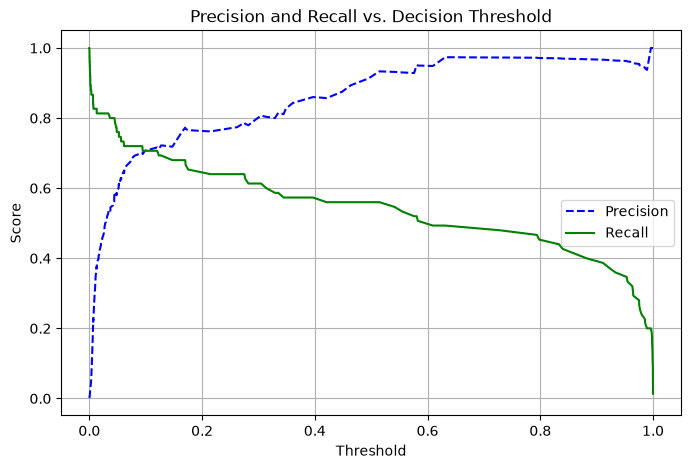

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot Precision and Recall vs Thresholds
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Decision Threshold")
plt.legend()
plt.grid()
plt.show()

In [57]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# VARIANT A: Class-Weighted Logistic Regression
model_weighted = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
y_proba_weighted = model_weighted.predict_proba(X_test)[:, 1]

# VARIANT B: SMOTE Oversampling (Applied ONLY on Training Set)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model_smote = LogisticRegression(
    solver='liblinear',
    class_weight=None,
    random_state=42
)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def print_model_performance(name, y_true, y_pred, y_proba):
    print(f"=== {name} ===")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (Fraud): {precision_score(y_true, y_pred):.4f}")
    print(f"Recall (Fraud):    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score (Fraud):  {f1_score(y_true, y_pred):.4f}")
    print(f"AUC-ROC:           {roc_auc_score(y_true, y_proba):.4f}")
    print(f"AUC-PR:            {average_precision_score(y_true, y_proba):.4f}\n")

print_model_performance("Variant A: Class-Weighted (Threshold = 0.50)", y_test, y_pred_weighted, y_proba_weighted)

print(f"SMOTE Verification:")
print(f"Original Training rows:  {len(X_train)} (Fraud cases: {y_train.sum()})")
print(f"Resampled Training rows: {len(X_train_smote)} (Fraud cases: {y_train_smote.sum()})\n")

print_model_performance("Variant B: SMOTE (Threshold = 0.50)", y_test, y_pred_smote, y_proba_smote)

=== Variant A: Class-Weighted (Threshold = 0.50) ===
Accuracy:          0.9844
Precision (Fraud): 0.0709
Recall (Fraud):    0.8933
F1-Score (Fraud):  0.1314
AUC-ROC:           0.9863
AUC-PR:            0.7620

SMOTE Verification:
Original Training rows:  227845 (Fraud cases: 417)
Resampled Training rows: 454856 (Fraud cases: 227428)

=== Variant B: SMOTE (Threshold = 0.50) ===
Accuracy:          0.9838
Precision (Fraud): 0.0684
Recall (Fraud):    0.8933
F1-Score (Fraud):  0.1271
AUC-ROC:           0.9852
AUC-PR:            0.7682



In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

def find_optimal_f1_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = np.where((precisions[:-1] + recalls[:-1]) > 0,
                         2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1]), 0)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx], precisions[best_idx], recalls[best_idx]

t_base, f1_base, p_base, r_base = find_optimal_f1_threshold(y_test, y_pred_proba)
t_weight, f1_weight, p_weight, r_weight = find_optimal_f1_threshold(y_test, y_proba_weighted)
t_smote, f1_smote, p_smote, r_smote = find_optimal_f1_threshold(y_test, y_proba_smote)

In [61]:
# Print statements for comparing models at their optimal F1 thresholds
print("Fair Model Comparison (at Optimal F1 Thresholds)")
print(f"Baseline:       Best Thresh = {t_base:.4f} | Max F1 = {f1_base:.4f} (Prec: {p_base:.4f}, Rec: {r_base:.4f})")
print(f"Class-Weighted: Best Thresh = {t_weight:.4f} | Max F1 = {f1_weight:.4f} (Prec: {p_weight:.4f}, Rec: {r_weight:.4f})")
print(f"SMOTE:          Best Thresh = {t_smote:.4f} | Max F1 = {f1_smote:.4f} (Prec: {p_smote:.4f}, Rec: {r_smote:.4f})")

Fair Model Comparison (at Optimal F1 Thresholds)
Baseline:       Best Thresh = 0.1700 | Max F1 = 0.7234 (Prec: 0.7727, Rec: 0.6800)
Class-Weighted: Best Thresh = 0.9999 | Max F1 = 0.8058 (Prec: 0.8750, Rec: 0.7467)
SMOTE:          Best Thresh = 1.0000 | Max F1 = 0.8235 (Prec: 0.9180, Rec: 0.7467)


In [ ]:
import os
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def log_fixed_threshold_fraud_run(
    run_name,
    model,
    X_tr,
    y_tr,
    X_te,
    y_te,
    shared_threshold=0.50,
    smote_applied=False,
    note=None,
):
    """Fits model, logs threshold-independent metrics (AUC-PR, AUC-ROC) as primary evaluation targets,
    and logs performance at a fixed shared threshold for illustrative comparison.
    """
    with mlflow.start_run(run_name=run_name):
        model.fit(X_tr, y_tr)

        y_te_proba = model.predict_proba(X_te)[:, 1]

        pr_auc = average_precision_score(y_te, y_te_proba)
        roc_auc = roc_auc_score(y_te, y_te_proba)

        preds = (y_te_proba >= shared_threshold).astype(int)
        prec = precision_score(y_te, preds, pos_label=1, zero_division=0)
        rec = recall_score(y_te, preds, pos_label=1, zero_division=0)
        f1 = f1_score(y_te, preds, pos_label=1, zero_division=0)
        flagged_count = int(preds.sum())

        # Parameters
        mlflow.log_params(
            {
                "model_type": model.__class__.__name__,
                "class_weight": str(
                    model.get_params().get("class_weight", None)
                ),
                "smote_applied": smote_applied,
                "evaluation_strategy": "fixed_shared_threshold",
                "fixed_threshold": shared_threshold,
                "C": model.get_params().get("C", 1.0),
                "random_state": model.get_params().get("random_state", 42),
            }
        )

        # Metrics
        mlflow.log_metrics(
            {
                "auc_pr": pr_auc,
                "auc_roc": roc_auc,
                "precision_at_fixed_threshold": prec,
                "recall_at_fixed_threshold": rec,
                "f1_at_fixed_threshold": f1,
                "flagged_at_fixed_threshold": flagged_count,
            }
        )

        mlflow.set_tag("primary_comparison_metric", "auc_pr")
        if note:
            mlflow.set_tag("note", note)

        # Artifacts
        os.makedirs("temp_artifacts", exist_ok=True)
        fig_pr, ax_pr = plt.subplots(figsize=(6, 4))
        PrecisionRecallDisplay.from_predictions(
            y_te, y_te_proba, ax=ax_pr, name=run_name
        )
        ax_pr.set_title(f"PR Curve - {run_name}")
        pr_path = f"temp_artifacts/{run_name}_pr.png"
        plt.tight_layout()
        plt.savefig(pr_path)
        plt.close(fig_pr)
        mlflow.log_artifact(pr_path)

        mlflow.sklearn.log_model(model, name="model")

        print(
            f"Logged '{run_name}' | Primary AUC-PR: {pr_auc:.4f} | AUC-ROC: {roc_auc:.4f} | "
            f"Illustrative (T={shared_threshold}): F1={f1:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, Flagged={flagged_count}"
        )

mlflow.set_experiment("FraudGuard")

# Shared baseline note for MLflow tags
saturation_note = (
    "Probability saturation near T=1.0 observed for resampled models; F1 is monotonically "
    "increasing with no valid interior local optimum. Primary evaluation relies on threshold-independent AUC-PR."
)

# Run evaluations at shared T=0.50
log_fixed_threshold_fraud_run(
    "baseline_logistic_regression",
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    shared_threshold=0.50,
    smote_applied=False,
    note="Baseline unweighted model evaluated at shared default threshold.",
)

log_fixed_threshold_fraud_run(
    "class_weighted_logistic_regression",
    model_weighted,
    X_train,
    y_train,
    X_test,
    y_test,
    shared_threshold=0.50,
    smote_applied=False,
    note=saturation_note,
)

log_fixed_threshold_fraud_run(
    "smote_logistic_regression",
    model_smote,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test,
    shared_threshold=0.50,
    smote_applied=True,
    note=saturation_note,
)


Logged 'baseline_logistic_regression' | Primary AUC-PR: 0.7402 | AUC-ROC: 0.9755 | Illustrative (T=0.5): F1=0.7000, Prec=0.9333, Rec=0.5600, Flagged=45
Logged 'class_weighted_logistic_regression' | Primary AUC-PR: 0.7620 | AUC-ROC: 0.9863 | Illustrative (T=0.5): F1=0.1314, Prec=0.0709, Rec=0.8933, Flagged=945
Logged 'smote_logistic_regression' | Primary AUC-PR: 0.7682 | AUC-ROC: 0.9852 | Illustrative (T=0.5): F1=0.1271, Prec=0.0684, Rec=0.8933, Flagged=979


In [64]:
import joblib
import mlflow
import mlflow.sklearn

mlflow.set_experiment("FraudGuard")
experiment = mlflow.get_experiment_by_name("FraudGuard")
if experiment is None:
    raise RuntimeError("FraudGuard experiment was not created. Run the training cells first.")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time DESC"],
    max_results=1,
)
if runs.empty:
    raise RuntimeError("No MLflow runs were found for the FraudGuard experiment.")

run_id = runs.iloc[0].run_id
model_uri = f"runs:/{run_id}/model"
baseline_model = mlflow.sklearn.load_model(model_uri)
joblib.dump(baseline_model, "baseline_logistic_regression.joblib")
print(f"Loaded model from run {run_id} and saved to baseline_logistic_regression.joblib")

Loaded model from run ce0c8be62a224d0eb3361d44c010f272 and saved to baseline_logistic_regression.joblib


In [ ]:
import pandas as pd

print(df["Amount"].describe())

fraud_idx = X_test[y_test == 1].head(5).index
legit_idx = X_test[y_test == 0].head(5).index

fraud_samples = df.loc[fraud_idx].copy()
legit_samples = df.loc[legit_idx].copy()

fraud_samples["label"] = "Fraud"
legit_samples["label"] = "Legitimate"

sample_df = pd.concat([fraud_samples, legit_samples], ignore_index=True)
sample_df.to_csv("sample_transactions.csv", index=False)
print(sample_df[["Time", "Amount", "label"]])

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
       Time  Amount       label
0  146022.0    1.18       Fraud
1  146026.0    2.22       Fraud
2  146179.0    0.77       Fraud
3  146344.0   94.82       Fraud
4  146998.0    8.00       Fraud
5  145248.0   50.00  Legitimate
6  145249.0   14.95  Legitimate
7  145249.0    7.70  Legitimate
8  145249.0    6.99  Legitimate
9  145250.0  460.71  Legitimate
